In [1]:
import os

# gets rid of irritating warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Data preprocessing

In [2]:
import matplotlib.pyplot as plt
import polars as pl
from datasets import load_dataset

dataset = load_dataset("PolyAI/banking77", trust_remote_code=True)

df_train = pl.from_arrow(dataset["train"].data.table)
df_test = pl.from_arrow(dataset["test"].data.table)

print(df_train.shape)
print(df_test.shape)

(10003, 2)
(3080, 2)


In [3]:
print(f"Number of texts: {df_train.height}")
print("Data type (Schema):")
print(df_train.schema)

Number of texts: 10003
Data type (Schema):
Schema([('text', String), ('label', Int64)])


In [4]:
df_labels = df_train.select("label").group_by("label").len()
print(df_labels.sort("label"))

shape: (77, 2)
┌───────┬─────┐
│ label ┆ len │
│ ---   ┆ --- │
│ i64   ┆ u32 │
╞═══════╪═════╡
│ 0     ┆ 159 │
│ 1     ┆ 110 │
│ 2     ┆ 126 │
│ 3     ┆ 87  │
│ 4     ┆ 127 │
│ …     ┆ …   │
│ 72    ┆ 41  │
│ 73    ┆ 135 │
│ 74    ┆ 121 │
│ 75    ┆ 180 │
│ 76    ┆ 163 │
└───────┴─────┘


Indeed labels go from 0 to 76

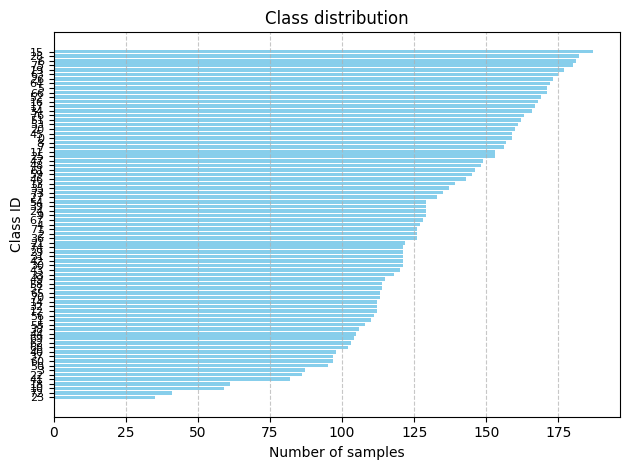

In [5]:
df_plot = df_labels.sort("len", descending=False)

plt.barh(df_plot["label"].cast(pl.Utf8), df_plot["len"], color='skyblue')
plt.xlabel("Number of samples")
plt.ylabel("Class ID")
plt.title("Class distribution")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
df_labels.select(pl.col("len")).describe()

statistic,len
str,f64
"""count""",77.0
"""null_count""",0.0
"""mean""",129.909091
"""std""",32.942207
"""min""",35.0
"""25%""",112.0
"""50%""",127.0
"""75%""",159.0
"""max""",187.0


We can see that there are pretty big differance in class size. To ensure that lets check that with chisquare test

In [7]:
from scipy import stats

chi2_stat, p_value = stats.chisquare(f_obs=df_labels["len"])
print(f"Chi2 Stat: {chi2_stat}, p-value: {p_value}")

Chi2 Stat: 634.8621413575928, p-value: 4.1433388459280655e-89


The p-value is really low. There are significant differances in class sizes.

In [8]:
df_text_length = df_train.with_columns(
    pl.col("text").str.len_chars().alias("text_length")
).select(pl.col("text_length"))
df_text_length.describe()

statistic,text_length
str,f64
"""count""",10003.0
"""null_count""",0.0
"""mean""",59.473758
"""std""",40.867901
"""min""",13.0
"""25%""",36.0
"""50%""",47.0
"""75%""",64.0
"""max""",433.0


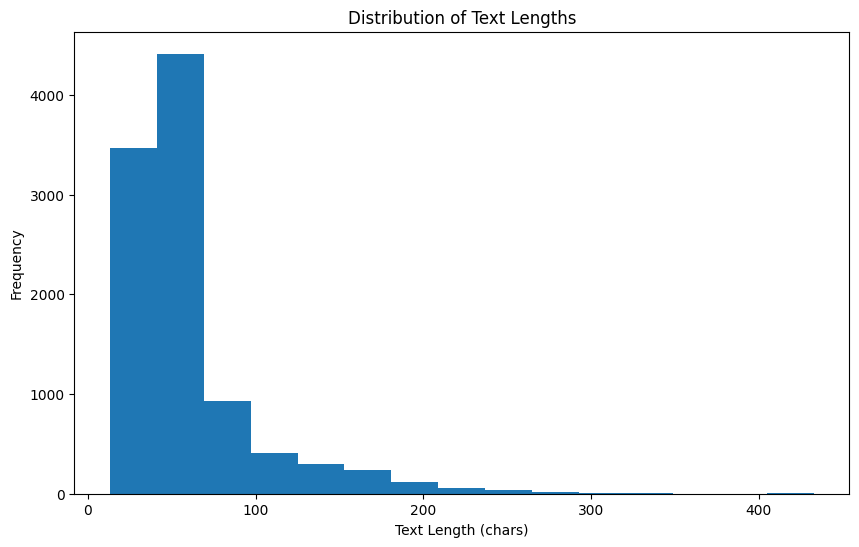

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df_text_length["text_length"], bins=15)
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length (chars)")
plt.ylabel("Frequency")
plt.show()  

As we can see most of the texts are quite short. There are several long texst but definitely much less than short one. Distribution is right-skewed.

## CleanLab for detecting and fixing data quality issues

In [10]:
import joblib
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_predict


def get_initial_model_data(texts: np.ndarray, labels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(texts, show_progress_bar=True)
    classifier = LogisticRegressionCV(max_iter=1000, class_weight='balanced', )
    pred_probs = cross_val_predict(classifier, embeddings, labels, method='predict_proba')

    return embeddings, pred_probs

In [11]:
texts = df_train["text"].to_numpy()
labels = df_train["label"].to_numpy()

embeddings, pred_probs = get_initial_model_data(texts, labels)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [12]:
print(embeddings.shape)
print(pred_probs.shape)

(10003, 384)
(10003, 77)


In [13]:
from cleanlab import Datalab

data_dict = {"texts": texts, "labels": labels}
lab = Datalab(data_dict, label_name="labels", task="classification")
lab.find_issues(pred_probs=pred_probs, features=embeddings)
lab.report()

Finding null issues ...
Finding label issues ...
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 632 issues found in the dataset.
Dataset Information: num_examples: 10003, num_classes: 77

Here is a summary of various issues found in your data:

    issue_type  num_issues
near_duplicate         350
         label         150
       outlier         131
       non_iid           1

Learn about each issue: https://docs.cleanlab.ai/stable/cleanlab/datalab/guide/issue_type_description.html
See which examples in your dataset exhibit each issue via: `datalab.get_issues(<ISSUE_NAME>)`

Data indices corresponding to top examples of each issue are shown below.


------------------ near_duplicate issues -------------------

About this issue:
	A (near) duplicate issue refers to two or more examples in
    a dataset that are extremely similar to each other, relative
  

## Near duplicate issue

In [14]:
duplicate_issues = lab.get_issues("near_duplicate")
duplicate_issues = duplicate_issues[duplicate_issues["is_near_duplicate_issue"]]
duplicate_issues = duplicate_issues.sort_values(by="near_duplicate_score")

In [15]:
for idx, row in duplicate_issues.head(10).iterrows():
    text = texts[idx]
    print(text)
    neighbors = texts[row["near_duplicate_sets"][:5]]
    print(f"Text: {text}")
    print(f"\tDuplicates: {neighbors}")
    print()


I put the wrong pin too many times and now it is blocked. Can you help me unblock it?
Text: 
I put the wrong pin too many times and now it is blocked. Can you help me unblock it?
	Duplicates: ['I put the wrong pin too many times and now it is blocked. Can you help me unblock it?']


I can't seem to be able to use my card



Text: 
I can't seem to be able to use my card



	Duplicates: ["I can't seem to be able to use my card"]

I can't seem to be able to use my card
Text: I can't seem to be able to use my card
	Duplicates: ["\nI can't seem to be able to use my card\n\n\n"]

Where can I withdraw money from?
Text: Where can I withdraw money from?
	Duplicates: ['\nWhere can I withdraw money from?']


Where can I withdraw money from?
Text: 
Where can I withdraw money from?
	Duplicates: ['Where can I withdraw money from?']

How can I reset my passcode?
Text: How can I reset my passcode?
	Duplicates: ['How can i reset my passcode ?' 'How do I reset my passcode?']

How can i reset my passcod

In [16]:
ids_to_drop = duplicate_issues.index.to_list()

df_deduplicated = (
    df_train
    .with_row_index(name="orig_index")      
    .filter(~pl.col("orig_index").is_in(ids_to_drop))
    .drop("orig_index")                     
)

In [17]:
df_deduplicated.shape

(9653, 2)

## Label issues

In [18]:
label_issues = lab.get_issues("label")
label_issues = label_issues[label_issues["is_label_issue"]]
label_issues = label_issues.sort_values(by="label_score")


top_label_issues_y_true = label_issues.head(10)["given_label"]
top_label_issues_y_pred = label_issues.head(10)["predicted_label"]
top_label_issues_idxs = label_issues.head(10).index
top_label_issues_texts = texts[top_label_issues_idxs]

print("Top 10 label issues")
for text, y_true, y_pred in zip(top_label_issues_texts, top_label_issues_y_true, top_label_issues_y_pred):
    print(f"y_true {y_true}, y_pred {y_pred}, text: {text}")
    print(f"prob true {pred_probs[texts.tolist().index(text)][y_true]}, prob pred {pred_probs[texts.tolist().index(text)][y_pred]}")
    print()

Top 10 label issues
y_true 11, y_pred 14, text: WHAT IS THE SOLUTION OF THIS PROBLEM
prob true 4.641757983187164e-05, prob pred 0.7869724196505127

y_true 29, y_pred 40, text: i am not a premium customer but i want a virtual card, how do i get it
prob true 0.00018571013393397408, prob pred 0.9339658169058807

y_true 41, y_pred 11, text: Can you tell me the status of my new card?
prob true 0.0003428905510038207, prob pred 0.9807205868839395

y_true 27, y_pred 7, text: please help me with this transfer, for some reason i can't transfer to a cryptocurency account
prob true 0.0008085969150158346, prob pred 0.975877733990435

y_true 14, y_pred 49, text: Can I use app to reset PIN attempts?
prob true 0.0009911935850372279, prob pred 0.9311529370246664

y_true 49, y_pred 38, text: Where do I find PIN for my card?
prob true 0.0010543570509195378, prob pred 0.9881349326097482

y_true 47, y_pred 62, text: i put money on my card and i dont see it on the balance
prob true 0.0010879658800423953, pr

So lets see the problem.

Example 1
"WHAT IS THE SOLUTION OF THIS PROBLEM" 
y_true -> card_arrival
y_pred -> card_not_working

This sentence is not precise at all. But is more likely to refer to some card issues.

Example 2
"i am not a premium customer but i want a virtual card, how do i get it"
y_true -> disposable_card_limits
y_pred -> getting_virtual_card

There is definitely label issue. That costumer would like to get virtual card

Example 3
Can you tell me the status of my new card?
y_true -> lost_or_stolen_card 
y_pred -> card_arrival

This question is more like asking when the card was delivered

In [19]:
df_corrections = pl.DataFrame({
    "orig_index": label_issues.index.to_numpy(),
    "new_label": label_issues["predicted_label"].to_numpy()
})


df_fixed = (
    df_deduplicated
    .with_row_index(name="orig_index")
    .join(df_corrections, on="orig_index", how="left")
    .with_columns(
        pl.coalesce(["new_label", "label"]).alias("label")
    )
    .drop("new_label")
)

In [20]:
sample_idx = label_issues.head(1).index[0]
df_fixed.filter(pl.col("orig_index") == sample_idx)

orig_index,text,label
u32,str,i64
93,"""Can you help me track my card?""",14


According to the paper "Label Errors in BANKING77"

Now we have the relevant label.

## Outliers

In [21]:
outlier_issues = lab.get_issues("outlier")
outlier_issues = outlier_issues[outlier_issues["is_outlier_issue"]]
outlier_issues = outlier_issues.sort_values(by="outlier_score")

for idx, row in outlier_issues.head(15).iterrows():
    text = texts[idx]
    print(f"Text: {text}")
    print()

Text: WHAT IS THE ATMOSPHERE OF IT

Text: what is the word?

Text: What is this witdrawal

Text: what is the matter?

Text: WHAT IS THE SOLUTION OF THIS PROBLEM

Text: I prefer Mastecard.

Text: I have made 5 attempts to make a very standard survey, yet I can't get it to work. What is the problem? Is there an issue related to your system?

Text: WHAT IS THE MAIN REASON OF THIS PROBLEM

Text: WHAT IS THE REASON FOR THAT

Text: why was i chargged

Text: I have a trasnger that is pending and wondered about it.

Text: As far as courtries go which ones are supported?

Text: How can I change my Rowlock ?

Text: Can I get support?

Text: The transger I tried to make failed.



There are some noises like "WHAT IS THE ATMOSPHERE OF IT", "what is the word?", "How can I change my Rowlock ?". We can also notice some general questions like "what is the matter?", "WHAT IS THE SOLUTION OF THIS PROBLEM", "WHAT IS THE MAIN REASON OF THIS PROBLEM", but it may be problem with uppercase comments. We have also a comment with typos like "What is this witdrawal", "I have a trasnger that is pending".


We should remove noises, for typos we can use some library to fix them or we can make augmentation.

## Training


In [22]:
import torch
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split


train_size = int(0.8 * len(df_fixed))
validation_size = int(0.2 * len(df_fixed))

df_pandas = df_fixed.with_columns(pl.col("label").cast(pl.Int64)).to_pandas()
df_train, df_valid = train_test_split(df_pandas, train_size=train_size, random_state=0, stratify=df_pandas["label"])
df_test = df_test.with_columns(pl.col("label").cast(pl.Int64)).to_pandas()

datasets_dict = DatasetDict()
datasets_dict["train"] = Dataset.from_pandas(df_train, split="train")
datasets_dict["valid"] = Dataset.from_pandas(df_valid, split="valid")
datasets_dict["test"] = Dataset.from_pandas(df_test, split="valid")



In [23]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

def tokenize(examples: dict) -> dict:
    encoded_examples = tokenizer(examples["text"], padding=True, truncation=True)
    encoded_examples["label"] = torch.tensor(examples["label"])
    return encoded_examples

num_cores = joblib.cpu_count(only_physical_cores=True)
datasets_tokenized = datasets_dict.map(tokenize, batched=True)

  File "c:\Users\zapar\Programowanie\Python\MlOps-course\homework6\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\zapar\AppData\Roaming\uv\python\cpython-3.11.13-windows-x86_64-none\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\zapar\AppData\Roaming\uv\python\cpython-3.11.13-windows-x86_64-none\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\zapar\AppData\Roaming\uv\python\cpython-3.11.13-windows-x86_64-none\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Map:   0%|          | 0/7722 [00:00<?, ? examples/s]

Map:   0%|          | 0/1931 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

In [24]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")

CUDA available: True
CUDA device count: 1


In [25]:
import os
import random

from sklearn.metrics import matthews_corrcoef
from torch.nn.functional import softmax
from sklearn.metrics import f1_score
from transformers import AutoModelForSequenceClassification, EvalPrediction, Trainer, TrainingArguments


# set determinism settings
os.environ["PYTHON_HASH_SEED"] = str(0)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", num_labels=77)

def compute_metrics(eval_pred: EvalPrediction) -> dict:
    logits, y_true = eval_pred.predictions, eval_pred.label_ids
    y_pred = np.argmax(logits, axis=-1)
    f1 = f1_score(y_true, y_pred, average="macro")
    return {"f1": f1}


training_args = TrainingArguments(
    output_dir="finetuned_model",
    # change num_train_epochs depending on your hardware
    # if lower, increase learning rate and decrease save_steps and eval_steps
    learning_rate=5e-5,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    eval_strategy="steps",
    save_steps=100,
    eval_steps=100,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1", 
    greater_is_better=True,
    seed=0,
    data_seed=0,
    fp16=True,  # comment this out if you have unsupported hardware
    #dataloader_num_workers=1,  # comment out if necessary
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=datasets_tokenized["train"],
    eval_dataset=datasets_tokenized["valid"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)
trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,F1
100,No log,3.540709,0.244873
200,No log,2.473588,0.473055
300,No log,1.657348,0.656709
400,No log,1.174777,0.717965
500,2.403600,0.894742,0.772633
600,2.403600,0.708228,0.810288
700,2.403600,0.606628,0.851095
800,2.403600,0.553303,0.869097
900,2.403600,0.509559,0.879361
1000,0.619900,0.493100,0.877604


TrainOutput(global_step=4830, training_loss=0.3923893819931378, metrics={'train_runtime': 478.7663, 'train_samples_per_second': 161.29, 'train_steps_per_second': 10.088, 'total_flos': 1948554524772276.0, 'train_loss': 0.3923893819931378, 'epoch': 10.0})

## Metrics

In [26]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report, accuracy_score
from scipy.special import softmax

In [27]:
predictions = trainer.predict(datasets_tokenized["test"])

logits = predictions.predictions
y_true = predictions.label_ids

y_pred = np.argmax(logits, axis=-1)
y_pred_proba = softmax(logits, axis=-1)

macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1-score: {macro_f1:.4f}")

Macro F1-score: 0.9192


In [28]:
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy:       {acc:.4f}")

Accuracy:       0.9192


In [29]:
macro_auroc = roc_auc_score(y_true, y_pred_proba, multi_class="ovo", average="macro")
print(f"Macro AUROC:    {macro_auroc:.4f}")

Macro AUROC:    0.9988


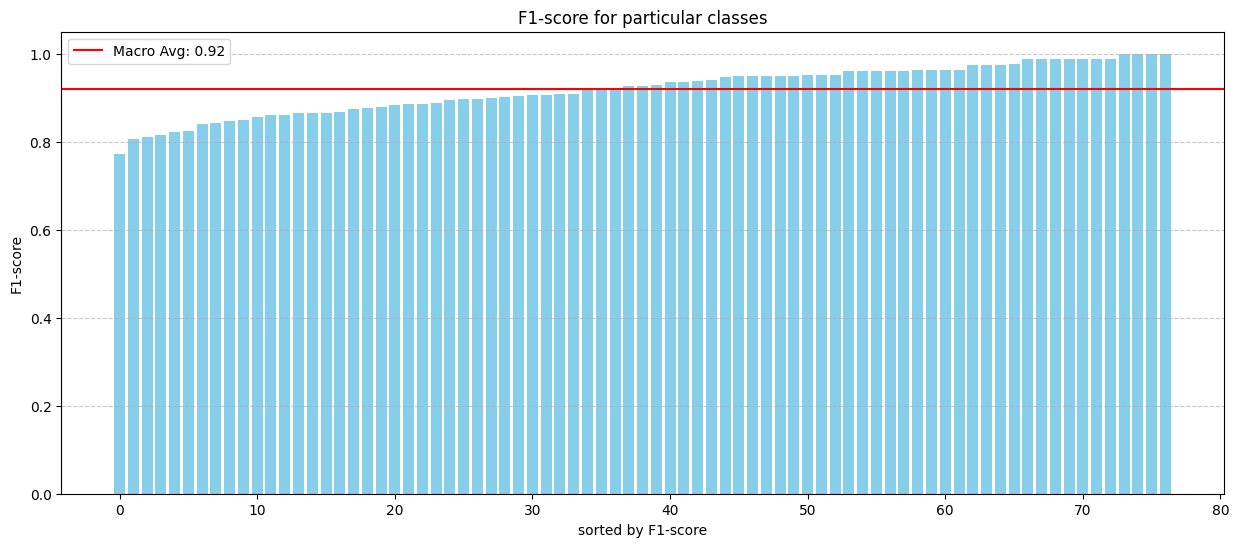

In [30]:
report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)


class_ids = []
f1_scores = []

for key, value in report.items():
    if key.isdigit():
        class_ids.append(int(key))
        f1_scores.append(value['f1-score'])


sorted_indices = np.argsort(f1_scores)
sorted_ids = np.array(class_ids)[sorted_indices]
sorted_scores = np.array(f1_scores)[sorted_indices]

plt.figure(figsize=(15, 6))
plt.bar(range(len(sorted_scores)), sorted_scores, color='skyblue')
plt.xlabel('sorted by F1-score')
plt.ylabel('F1-score')
plt.title('F1-score for particular classes')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.axhline(y=macro_f1, color='r', linestyle='-', label=f'Macro Avg: {macro_f1:.2f}')
plt.legend()
plt.show()

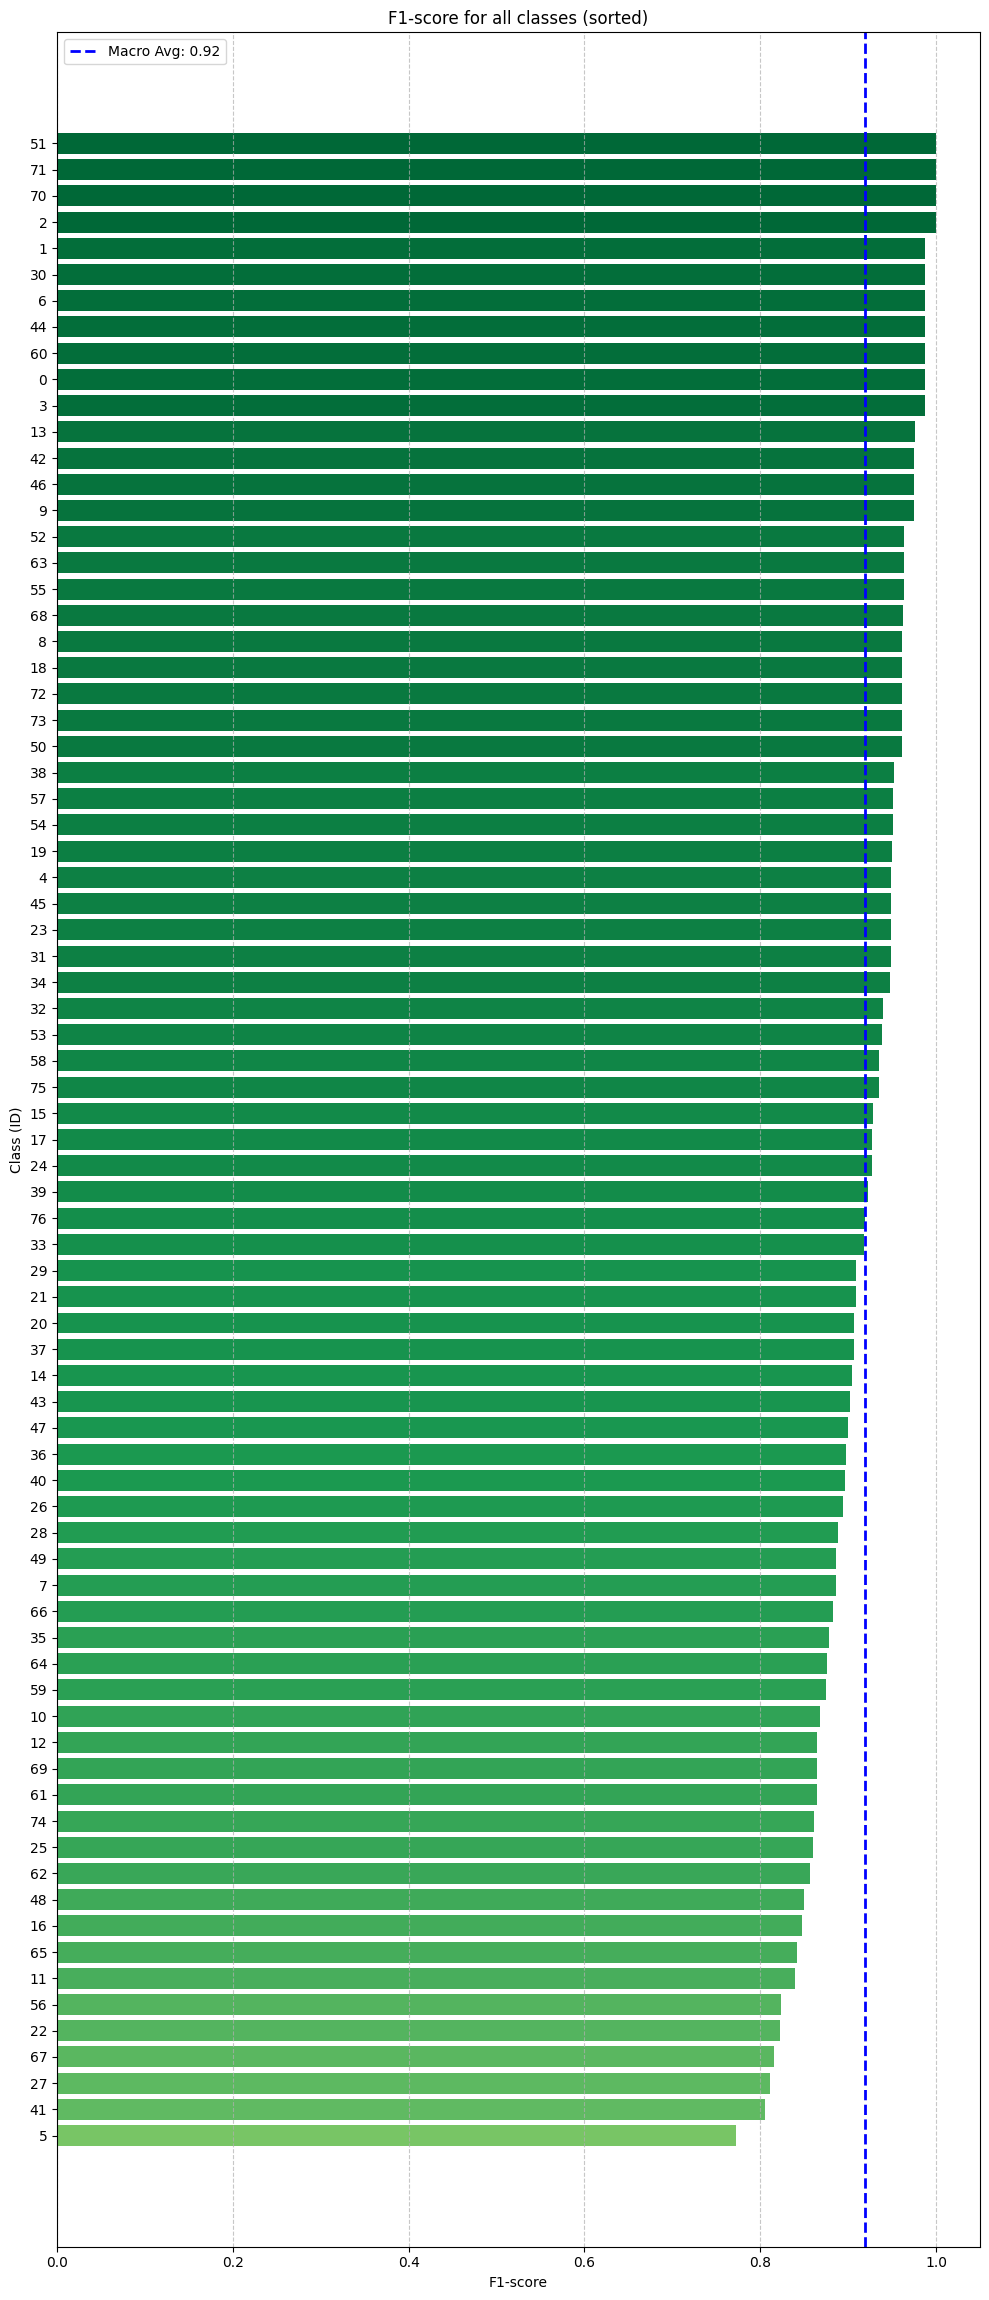

In [31]:
import pandas as pd

df_report = pd.DataFrame(report).transpose()
df_classes = df_report.drop(['accuracy', 'macro avg', 'weighted avg'])
df_classes = df_classes.sort_values(by='f1-score', ascending=True)
plt.figure(figsize=(10, len(df_classes) * 0.3)) 

norm = plt.Normalize(0, 1)
colors = plt.cm.RdYlGn(norm(df_classes['f1-score'].values))

bars = plt.barh(df_classes.index, df_classes['f1-score'], color=colors)
plt.xlabel('F1-score')
plt.ylabel('Class (ID)')
plt.title('F1-score for all classes (sorted)')
plt.xlim(0, 1.05)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=macro_f1, color='blue', linestyle='--', linewidth=2, label=f'Macro Avg: {macro_f1:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

Macro AUROC is 0.9946, so model can easily distinguish classes, regardless of the threshold. 

Macro f1 is pretty similar to a paper one.

Average macro f1 is really high (92%). It doesn't discriminate any of the class. The weakest one has still ~78%, it's not that bad at all.

## Behavioral testing

In [ ]:
import torch
import pandas as pd
import numpy as np
from torch.nn.functional import softmax
from giskard import Model as GiskardModel, Dataset as GiskardDataset, scan

model.eval()

@torch.no_grad()
def prediction_function(df: pd.DataFrame) -> np.ndarray:
    inputs = tokenizer(
        df["text"].tolist(), 
        padding=True, 
        truncation=True, 
        max_length=512, 
        return_tensors="pt"
    ).to(model.device) 

    logits = model(**inputs).logits
    probs = softmax(logits, dim=-1)
    
    return probs.detach().cpu().numpy()

labels_list = list(range(77))

giskard_model = GiskardModel(
    model=prediction_function,
    model_type="classification",
    name="Banking77 DistilBERT",
    classification_labels=labels_list,
    feature_names=["text"]
)


val_labels = datasets_tokenized["valid"]["label"]
if isinstance(val_labels, torch.Tensor):
    val_labels = val_labels.tolist()
elif hasattr(val_labels[0], 'item'):
    val_labels = [l.item() for l in val_labels]

val_df = pd.DataFrame({
    "text": tokenizer.batch_decode(datasets_tokenized["valid"]["input_ids"], skip_special_tokens=True),
    "label": val_labels
})

giskard_dataset = GiskardDataset(
    df=val_df,
    target="label",
    name="Validation Set"
)

print("Rozpoczynam skanowanie Giskardem...")
results = scan(giskard_model, giskard_dataset)
display(results)

results.to_html("model_report.html")

2025-11-22 16:48:10,482 pid:17816 MainThread giskard.models.automodel INFO     Your 'prediction_function' is successfully wrapped by Giskard's 'PredictionFunctionModel' wrapper class.
2025-11-22 16:48:10,622 pid:17816 MainThread giskard.datasets.base INFO     Your 'pandas.DataFrame' is successfully wrapped by Giskard's 'Dataset' wrapper class.
Rozpoczynam skanowanie Giskardem...
2025-11-22 16:48:10,632 pid:17816 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-11-22 16:48:10,661 pid:17816 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (10, 2) executed in 0:00:00.034114
2025-11-22 16:48:10,673 pid:17816 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-11-22 16:48:10,703 pid:17816 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (1, 2) executed in 0:00:00.038836
2025-11-22 16:48:10,713 pid:178

<iframe id="scan-2752072887568" srcdoc="<!doctype html>
<html lang="en">

<head>
 <title>Giskard Scan Results</title>
 <base target="_blank">
 <meta charset="utf-8">
 
<style>pre code.hljs{display:block;overflow-x:auto;padding:1em}code.hljs{padding:3px 5px}
/*!
 Theme: GitHub Dark
 Description: Dark theme as seen on github.com
 Author: github.com
 Maintainer: @Hirse
 Updated: 2021-05-15

 Outdated base version: https://github.com/primer/github-syntax-dark
 Current colors taken from GitHub's CSS
*/.hljs{background:#0d1117;color:#c9d1d9}.hljs-doctag,.hljs-keyword,.hljs-meta .hljs-keyword,.hljs-template-tag,.hljs-template-variable,.hljs-type,.hljs-variable.language_{color:#ff7b72}.hljs-title,.hljs-title.class_,.hljs-title.class_.inherited__,.hljs-title.function_{color:#d2a8ff}.hljs-attr,.hljs-attribute,.hljs-literal,.hljs-meta,.hljs-number,.hljs-operator,.hljs-selector-attr,.hljs-selector-class,.hljs-selector-id,.hljs-variable{color:#79c0ff}.hljs-meta .hljs-string,.hljs-regexp,.hljs-string{color:#a5d6ff}.hljs-built_in,.hljs-symbol{color:#ffa657}.hljs-code,.hljs-comment,.hljs-formula{color:#8b949e}.hljs-name,.hljs-quote,.hljs-selector-pseudo,.hljs-selector-tag{color:#7ee787}.hljs-subst{color:#c9d1d9}.hljs-section{color:#1f6feb;font-weight:700}.hljs-bullet{color:#f2cc60}.hljs-emphasis{color:#c9d1d9;font-style:italic}.hljs-strong{color:#c9d1d9;font-weight:700}.hljs-addition{background-color:#033a16;color:#aff5b4}.hljs-deletion{background-color:#67060c;color:#ffdcd7}.hljs-copy-wrapper{overflow:hidden;position:relative}.hljs-copy-button:focus,.hljs-copy-wrapper:hover .hljs-copy-button{transform:translateX(0)}.hljs-copy-button{background-color:#2d2b57;background-color:var(--hljs-theme-background);background-image:url('data:image/svg+xml;charset=utf-8,<svg xmlns="http://www.w3.org/2000/svg" width="16" height="16" fill="none" viewBox="0 0 24 24"><path fill="%23fff" fill-rule="evenodd" d="M6 5a1 1 0 0 0-1 1v14a1 1 0 0 0 1 1h12a1 1 0 0 0 1-1V6a1 1 0 0 0-1-1h-2a1 1 0 1 1 0-2h2a3 3 0 0 1 3 3v14a3 3 0 0 1-3 3H6a3 3 0 0 1-3-3V6a3 3 0 0 1 3-3h2a1 1 0 0 1 0 2H6Z" clip-rule="evenodd"/><path fill="%23fff" fill-rule="evenodd" d="M7 3a2 2 0 0 1 2-2h6a2 2 0 0 1 2 2v2a2 2 0 0 1-2 2H9a2 2 0 0 1-2-2V3Zm8 0H9v2h6V3Z" clip-rule="evenodd"/></svg>');background-position:50%;background-repeat:no-repeat;border:1px solid #ffffff22;border-radius:.25rem;color:#fff;height:2rem;position:absolute;right:1em;text-indent:-9999px;top:1em;transition:background-color .2s ease,transform .2s ease-out;width:2rem}.hljs-copy-button:hover{border-color:#ffffff44}.hljs-copy-button:active{border-color:#ffffff66}.hljs-copy-button[data-copied=true]{background-image:none;text-indent:0;width:auto}@media (prefers-reduced-motion){.hljs-copy-button{transition:none}}.hljs-copy-alert{clip:rect(0 0 0 0);-webkit-clip-path:inset(50%);clip-path:inset(50%);height:1px;overflow:hidden;position:absolute;white-space:nowrap;width:1px}
/*! tailwindcss v3.3.2 | MIT License | https://tailwindcss.com*/*,:after,:before{border:0 solid #e5e7eb;box-sizing:border-box}:after,:before{--tw-content:""}html{-webkit-text-size-adjust:100%;font-feature-settings:normal;font-family:ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica Neue,Arial,Noto Sans,sans-serif,Apple Color Emoji,Segoe UI Emoji,Segoe UI Symbol,Noto Color Emoji;font-variation-settings:normal;line-height:1.5;-moz-tab-size:4;-o-tab-size:4;tab-size:4}body{line-height:inherit;margin:0}hr{border-top-width:1px;color:inherit;height:0}abbr:where([title]){-webkit-text-decoration:underline dotted;text-decoration:underline dotted}h1,h2,h3,h4,h5,h6{font-size:inherit;font-weight:inherit}a{color:inherit;text-decoration:inherit}b,strong{font-weight:bolder}code,kbd,pre,samp{font-family:ui-monospace,SFMono-Regular,Menlo,Monaco,Consolas,Liberation Mono,Courier New,monospace;font-size:1em}small{font-size:80%}sub,sup{font-size:75%;line-height:0;position:relative;vertical-align:baseline}sub{bottom:-.25em}sup{top:-.5em}table{border-collapse:

There are several issues in model. 23.7% of samples changed their prediction after perturbation. The model is overfitting to exact keywords. When we switch gender 9.09% responds changed their output. However, there were only 11 samples, so the results are not entirely reliable. The most significant problem is switching countrie. The model has likely memorized specific country names as features for specific classes. 19.51 percent of failure is definitively too much.

## Local explainability

In [49]:
from copy import deepcopy

from captum.attr import InputXGradient, configure_interpretable_embedding_layer
from captum.attr import visualization as vis


class BERTModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, inputs, attention_mask):
        return self.model(inputs, attention_mask=attention_mask)[0]

def explain_text(model, text: str, y_true: int, target_class: int = None):
    # make sure we compute gradients as necessary
    for param in model.distilbert.parameters():
        param.requires_grad = True

    tokenizer_output = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
        return_tensors="pt",
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer_output = tokenizer_output.to(device)
    tokens = tokenizer.convert_ids_to_tokens(tokenizer_output["input_ids"][0])

    if target_class is None:
        with torch.no_grad():
            logits = model(**tokenizer_output).logits
            probs = softmax(logits, dim=1)[0]
            pred_class = int(torch.argmax(probs))
    else:
        pred_class = target_class

    model_copy = deepcopy(model)
    interpretable_embedding_layer = configure_interpretable_embedding_layer(
        model_copy, "distilbert.embeddings"
    )
    input_embeddings = interpretable_embedding_layer.indices_to_embeddings(
        tokenizer_output["input_ids"]
    )

    model_wrapper = BERTModelWrapper(model_copy)
    input_x_gradient = InputXGradient(model_wrapper)
    attributions = input_x_gradient.attribute(
        input_embeddings,
        target=pred_class,
        additional_forward_args=tokenizer_output["attention_mask"],
    )

    # mean normalization
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    attributions = [float(a) for a in attributions]

    with torch.no_grad():
        logits = model(**tokenizer_output).logits
        probs = softmax(logits, dim=1)[0]
        y_pred = int(torch.argmax(probs))
        y_pred_proba = probs[y_pred].item()

    # remove [CLS] and [SEP] tokens
    attributions = attributions[1:-1]
    tokens = tokens[1:-1]

    vis_record = vis.VisualizationDataRecord(
        word_attributions=attributions,
        pred_prob=y_pred_proba,
        pred_class=y_pred,
        true_class=y_true,
        attr_class=pred_class,
        attr_score=sum(attributions),
        raw_input_ids=tokens,
        convergence_score=0
    )

    vis.visualize_text([vis_record])

random_samples = df_test.sample(n=3, random_state=114)
for index, row in random_samples.iterrows():
    text = row['text']
    label = int(row['label'])

    explain_text(model, text, label)

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
26,26 (0.99),26,0.05,i was at the atm trying to made a withdraw and i was declined .


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
54,54 (0.99),54,-0.64,tell me which cards and what currency is supported .


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
30,30 (0.99),30,-1.40,is it possible to edit my personal details on the app ?


Example 1

class: "declined_cash_withdrawal" (label 26) - The model is pretty logical. It focused on "atm", that define where an occurrence happened. 

Example 2 
class: "supported_cards_and_currencies" (label 54) This is pretty strange because it marked currency as red. That is pretty strange that word currency has negative impact on prediction, maybe there are several differant classes that fit better to that word/4

Example 3 
class "edit_personal_details" (Label 30) It marked "possible", "edit", "personal" as green. That is correct and logical. Word "details" is too general.  


Generally model is focused on right parts of text, but there are few several strange situations.